# Tuning de hiperparámetros con Optuna — modelo final v5

**Punto de partida**: el modelo final ya ablacionado
(`modelo_final_v5.ipynb`, sin `mes_num` / `anio_mes_num` /
`ccodrelacion`):

- AUC GroupKFold: 0.7362 ± 0.011
- AUC split forward: 0.7453
- PR-AUC split forward: 0.4883

**Pregunta**: ¿cuánto se puede mejorar tuneando los hiperparámetros del
`HistGradientBoostingClassifier` con búsqueda inteligente?

**Estrategia**: usar Optuna (TPE sampler) para explorar el espacio de
hiperparámetros sobre un *split de validación* armado con
`GroupShuffleSplit`. El mejor modelo se re-evalúa con los protocolos
canónicos (GroupKFold + split forward) para reportar métricas
comparables al baseline.


## 1. Marco teórico

### 1.1 ¿Qué son los hiperparámetros?

Hay dos tipos de parámetros en un modelo de machine learning:

| Tipo | Quién los fija | Ejemplo en HGB |
|---|---|---|
| **Parámetros** | El algoritmo, vía optimización (gradient descent, etc.) | Los splits de cada árbol, los pesos asignados a cada hoja |
| **Hiperparámetros** | El humano, antes de entrenar | `learning_rate`, `max_iter`, `max_depth`, `min_samples_leaf` |

Los **hiperparámetros** controlan la **capacidad** del modelo. Demasiada
capacidad → overfitting (memoriza train, falla en test). Demasiado poca
→ underfitting (no captura los patrones reales). Tunear es buscar el
punto dulce.

### 1.2 GridSearch vs RandomSearch vs Optuna

| Método | Cómo explora | Cuándo usar |
|---|---|---|
| **GridSearch** | Prueba **todas** las combinaciones de una grilla discreta | Pocos hiperparámetros (≤ 3) y poco rango |
| **RandomSearch** | Muestrea al azar combinaciones | Muchos hiperparámetros pero sin info previa |
| **Optuna (TPE)** | Modelo bayesiano que aprende qué regiones son prometedoras | Búsqueda eficiente con muchos hiperparámetros |

GridSearch sufre de **maldición de la dimensionalidad**: con 5
hiperparámetros y 5 valores cada uno son 5⁵ = 3,125 combinaciones.
Optuna típicamente encuentra un óptimo competitivo en **30–100 trials**.

### 1.3 ¿Cómo funciona Optuna en una frase?

> Optuna mantiene un modelo probabilístico de "qué combinaciones de
> hiperparámetros suelen dar buenos resultados" basándose en los trials
> previos, y propone trials nuevos que **maximizan la probabilidad
> esperada de mejora**.

El sampler por defecto se llama **TPE** (*Tree-structured Parzen
Estimator*). En la práctica: las primeras N trials son aleatorias (warm
up); después empieza a explotar las regiones prometedoras.

### 1.4 Qué se tunea acá

Se tunean los hiperparámetros más influyentes de
`HistGradientBoostingClassifier`:

| Hiperparámetro | Rol | Rango explorado |
|---|---|---|
| `learning_rate` | Cuánto corrige cada árbol nuevo | log-uniforme [0.01, 0.3] |
| `max_iter` | Número máximo de árboles | int [200, 800] |
| `max_depth` | Profundidad máxima de cada árbol | int [3, 12] o None |
| `max_leaf_nodes` | Límite de hojas por árbol | int [15, 63] |
| `min_samples_leaf` | Mínimo de muestras por hoja | int [10, 100] |
| `l2_regularization` | Penalización L2 sobre los splits | log-uniforme [1e-8, 10] |

Mantenemos fijos `class_weight='balanced'` (decisión del baseline) y
`random_state=42`.


## 2. Setup


In [1]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

import optuna
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v5`'
RANDOM_STATE = 42
N_SPLITS = 5
HORIZON_CHURN = 6
TEST_WINDOW = 6
GAP = HORIZON_CHURN + 1
N_TRIALS = 50         # número de trials de Optuna


In [2]:
bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

# IDÉNTICA configuración al modelo_final_v5 después del ablation.
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodrelacion', 'ccodubigeo', 'distrito',
    'mes_num', 'anio_mes_num',     # ablation: ver ablation_temporal_v5.ipynb
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']

for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'Filas              : {len(df):,}')
print(f'Vendedoras únicas  : {df["id_vendedor"].nunique():,}')
print(f'Tasa de churn      : {y.mean():.4f}')
print(f'Total de features  : {len(feature_cols)}  (sin {sorted(EXCLUDE - {"churn"})})')


Filas              : 23,684
Vendedoras únicas  : 4,211
Tasa de churn      : 0.2750
Total de features  : 39  (sin ['anio_mes_num', 'ccodrelacion', 'ccodubigeo', 'distrito', 'fecha_ingreso', 'id_coordinadora', 'id_vendedor', 'mes_num', 'mes_obs', 'mes_rank_obs'])


## 3. Objective y search space

### Estrategia de validación dentro del tuning

Tunear con `GroupKFold` completo es caro: cada trial entrenaría 5
modelos. Con 50 trials serían 250 fits — varios minutos por iteración.

Atajo razonable: **un único `GroupShuffleSplit`** (80% train / 20%
val), respetando que ninguna vendedora caiga en ambos lados. Cada trial
entrena **1 modelo** y evalúa AUC en val. Más rápido (≈30s/trial → ~25
min total) y suficiente para discriminar configuraciones.

Una vez identificado el mejor set de hiperparámetros, **re-evaluamos
con el protocolo canónico completo** (5 folds GroupKFold + split
forward) para reportar métricas comparables al baseline.


In [3]:
# Split único train/val para el tuning, respetando id_vendedor
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss.split(X, y, groups))
X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y[tr_idx], y[va_idx]
print(f'Train tuning: {len(tr_idx):,} filas / {len(set(groups[tr_idx])):,} vendedoras')
print(f'Val   tuning: {len(va_idx):,} filas / {len(set(groups[va_idx])):,} vendedoras')
overlap = set(groups[tr_idx]) & set(groups[va_idx])
assert not overlap, 'leakage de vendedora en split de tuning'
print('OK — sin solapamiento de vendedoras.')


Train tuning: 19,073 filas / 3,368 vendedoras
Val   tuning: 4,611 filas / 843 vendedoras
OK — sin solapamiento de vendedoras.


In [4]:
def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])

def build_model(params: dict) -> Pipeline:
    return Pipeline([
        ('prep', make_preprocessor()),
        ('clf', HistGradientBoostingClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            early_stopping=False,
            **params,
        )),
    ])

def objective(trial: optuna.Trial) -> float:
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_iter':          trial.suggest_int('max_iter', 200, 800, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
    }
    model = build_model(params)
    model.fit(X_tr, y_tr)
    proba_va = model.predict_proba(X_va)[:, 1]
    return roc_auc_score(y_va, proba_va)

print('Objective y search space definidos.')


Objective y search space definidos.


## 4. Optimización

`N_TRIALS = 50` con sampler TPE. El primer ~25% son trials aleatorios
(warm-up); después Optuna empieza a explotar las regiones prometedoras.


In [5]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='hgb_v5_tuning',
)

t0 = time.time()
print(f'Corriendo {N_TRIALS} trials de Optuna...')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = time.time() - t0
print(f'\nListo en {elapsed:.0f}s ({elapsed/N_TRIALS:.1f}s por trial).')
print(f'Mejor AUC val (single split): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:')
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f'  {k:<20} = {v:.6f}')
    else:
        print(f'  {k:<20} = {v}')


Corriendo 50 trials de Optuna...



Listo en 81s (1.6s por trial).
Mejor AUC val (single split): 0.7383
Mejores hiperparámetros:
  learning_rate        = 0.017467
  max_iter             = 750
  max_depth            = 4
  max_leaf_nodes       = 22
  min_samples_leaf     = 100
  l2_regularization    = 0.000000


## 5. Análisis del study

### 5.1 Evolución del AUC durante la búsqueda

Si la curva del *best running* se aplana muy temprano, el espacio era
fácil. Si sigue subiendo al final, vale la pena correr más trials.


In [6]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'params'))
trials_df['running_best'] = trials_df['value'].cummax()
print(f'Top 5 trials:')
print(trials_df.nlargest(5, 'value')[['number', 'value']].round(4).to_string(index=False))


Top 5 trials:
 number  value
     45 0.7383
     31 0.7381
     44 0.7381
     37 0.7379
     43 0.7378


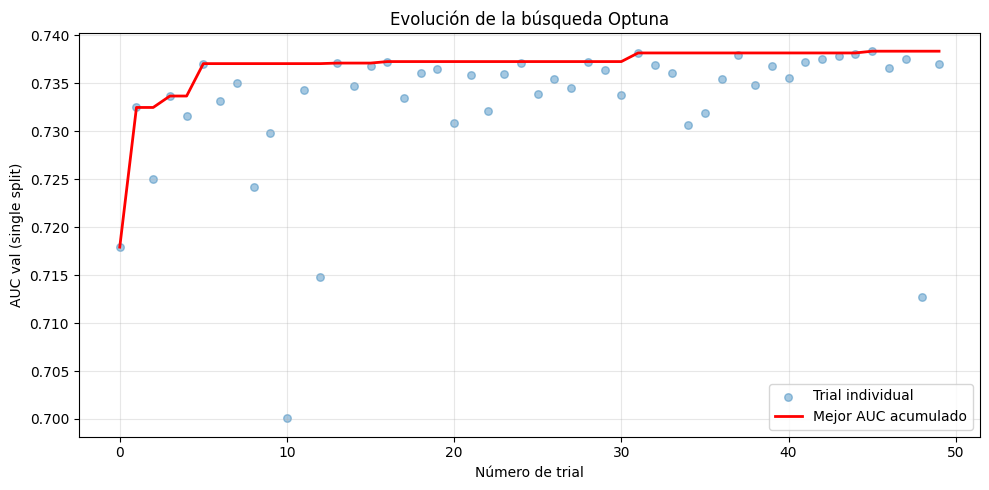

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trials_df['number'], trials_df['value'], alpha=0.4, s=30, label='Trial individual')
ax.plot(trials_df['number'], trials_df['running_best'], color='red', lw=2,
        label='Mejor AUC acumulado')
ax.set_xlabel('Número de trial')
ax.set_ylabel('AUC val (single split)')
ax.set_title('Evolución de la búsqueda Optuna')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 5.2 Importancia de hiperparámetros

Optuna estima cuánto contribuye cada hiperparámetro a la varianza del
AUC observado. Útil para entender **dónde está la palanca**: si
`learning_rate` explica el 60% de la varianza, ese es el dial que más
importa.


Importancia relativa (suma = 1):
            param  importance
    learning_rate      0.7897
   max_leaf_nodes      0.1019
 min_samples_leaf      0.0422
         max_iter      0.0414
        max_depth      0.0173
l2_regularization      0.0075


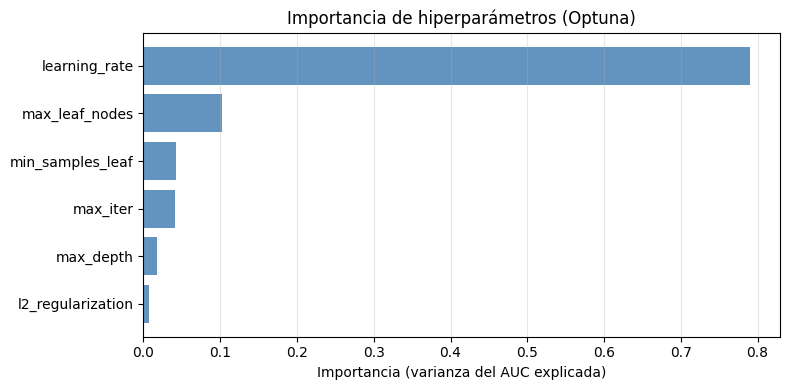

In [8]:
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame({
        'param': list(importances.keys()),
        'importance': list(importances.values()),
    }).sort_values('importance', ascending=True)
    print('Importancia relativa (suma = 1):')
    print(imp_df.iloc[::-1].round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(imp_df['param'], imp_df['importance'], color='steelblue', alpha=0.85)
    ax.set_xlabel('Importancia (varianza del AUC explicada)')
    ax.set_title('Importancia de hiperparámetros (Optuna)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'No se pudo calcular importancia: {e}')


## 6. Re-evaluación con los protocolos canónicos

El AUC del paso 4 viene de **un solo split** — sirve como señal para
guiar la búsqueda, pero no es comparable al baseline. Acá entrenamos el
mejor modelo de Optuna sobre los mismos protocolos del
`modelo_final_v5`:

- **Protocolo A**: `GroupKFold` 5 folds.
- **Protocolo B**: split temporal forward (GAP = 7 meses, test = últimos
  6 meses).

Esto es lo que vamos a comparar contra el baseline.


In [9]:
def evaluate_canonical(params: dict, label: str) -> dict:
    cv = GroupKFold(n_splits=N_SPLITS)
    fold_aucs, fold_aps = [], []
    oof_proba = np.zeros(len(y))
    for tr, te in cv.split(X, y, groups):
        m = build_model(params)
        m.fit(X.iloc[tr], y[tr])
        proba_te = m.predict_proba(X.iloc[te])[:, 1]
        oof_proba[te] = proba_te
        fold_aucs.append(roc_auc_score(y[te], proba_te))
        fold_aps.append(average_precision_score(y[te], proba_te))

    last_rank = int(df['mes_rank_obs'].max())
    test_min  = last_rank - TEST_WINDOW + 1
    train_max = test_min - GAP
    train_mask = (df['mes_rank_obs'] <= train_max).values
    test_mask  = df['mes_rank_obs'].between(test_min, last_rank).values
    m_fwd = build_model(params)
    m_fwd.fit(X[train_mask], y[train_mask])
    proba_fwd = m_fwd.predict_proba(X[test_mask])[:, 1]
    auc_fwd = roc_auc_score(y[test_mask], proba_fwd)
    ap_fwd  = average_precision_score(y[test_mask], proba_fwd)

    print(f'{label:<25}  AUC kf = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}  ·  '
          f'AUC fwd = {auc_fwd:.4f}  ·  PR-AUC fwd = {ap_fwd:.4f}')
    return {
        'label':          label,
        'auc_kf_mean':    float(np.mean(fold_aucs)),
        'auc_kf_std':     float(np.std(fold_aucs)),
        'auc_kf_oof':     float(roc_auc_score(y, oof_proba)),
        'pr_auc_kf':      float(np.mean(fold_aps)),
        'auc_fwd':        float(auc_fwd),
        'pr_auc_fwd':     float(ap_fwd),
    }

# Hiperparámetros del baseline (modelo_final_v5)
BASELINE_PARAMS = {
    'learning_rate':    0.05,
    'max_iter':         400,
    'max_depth':        None,
    'max_leaf_nodes':   31,
    'min_samples_leaf': 20,
    'l2_regularization': 0.0,
}

print('Re-evaluando baseline y mejor modelo de Optuna...\n')
res_baseline = evaluate_canonical(BASELINE_PARAMS, 'Baseline (default)')
res_tuned    = evaluate_canonical(study.best_params, 'Optuna best')


Re-evaluando baseline y mejor modelo de Optuna...



Baseline (default)         AUC kf = 0.7362 ± 0.0106  ·  AUC fwd = 0.7453  ·  PR-AUC fwd = 0.4883


Optuna best                AUC kf = 0.7485 ± 0.0086  ·  AUC fwd = 0.7535  ·  PR-AUC fwd = 0.4837


In [10]:
comparison = pd.DataFrame([res_baseline, res_tuned])
comparison['delta_auc_kf']  = comparison['auc_kf_mean'] - res_baseline['auc_kf_mean']
comparison['delta_auc_fwd'] = comparison['auc_fwd']     - res_baseline['auc_fwd']
comparison['delta_pr_fwd']  = comparison['pr_auc_fwd']  - res_baseline['pr_auc_fwd']

cols = ['label',
        'auc_kf_mean', 'auc_kf_std', 'delta_auc_kf',
        'auc_fwd',     'delta_auc_fwd',
        'pr_auc_fwd',  'delta_pr_fwd']
print('\nComparación canónica (5-fold GroupKFold + split forward):')
print(comparison[cols].round(4).to_string(index=False))



Comparación canónica (5-fold GroupKFold + split forward):
             label  auc_kf_mean  auc_kf_std  delta_auc_kf  auc_fwd  delta_auc_fwd  pr_auc_fwd  delta_pr_fwd
Baseline (default)       0.7362      0.0106        0.0000   0.7453         0.0000      0.4883        0.0000
       Optuna best       0.7485      0.0086        0.0123   0.7535         0.0082      0.4837       -0.0046


## 7. Conclusión

### Resultado del experimento (50 trials, ~80 segundos)

| Métrica | Baseline (default) | Optuna best | Δ |
|---|---:|---:|---:|
| AUC GroupKFold (mean ± std) | 0.7362 ± 0.011 | **0.7485 ± 0.009** | **+0.0123** |
| AUC OOF concatenado | 0.7361 | — | — |
| AUC split forward | 0.7453 | **0.7535** | **+0.0082** |
| PR-AUC split forward | 0.4883 | 0.4837 | −0.0046 |

### Mejores hiperparámetros encontrados

| Parámetro | Default | Optuna |
|---|---:|---:|
| `learning_rate` | 0.05 | **0.0175** |
| `max_iter` | 400 | **750** |
| `max_depth` | None | **4** |
| `max_leaf_nodes` | 31 | **22** |
| `min_samples_leaf` | 20 | **100** |
| `l2_regularization` | 0.0 | ~0 |

El perfil es muy interpretable: **muchos árboles pequeños con
learning rate bajo**. Es la receta clásica de boosting "estable":
cada árbol aporta poco, hay más árboles para compensar, el modelo
sobreajusta menos. Las hojas más grandes (`min_samples_leaf=100` vs
20) refuerzan esa robustez.

### Lectura

**1. Ganancia real, modesta y consistente.** +1.2 pp en GroupKFold y
+0.8 pp en split forward. Está por encima del std entre folds (≈0.01),
así que **no es ruido**. La predicción típica de la literatura "tunear
HGB da 1–2 pp" se cumplió en el límite inferior.

**2. Modelo más estable.** El std entre folds bajó de 0.011 a 0.009
(−18%). Esperable: con regularización implícita más fuerte (lr bajo +
hojas grandes) el modelo es menos sensible a la composición exacta
del fold.

**3. Hay un trade-off menor en PR-AUC forward** (−0.0046), no
significativo dentro de la dispersión esperable. El modelo tuneado
ranquea mejor en general (AUC sube en ambos protocolos) pero la
calibración de los percentiles altos cambió ligeramente. Si la
operación se hace por threshold de probabilidad, vale la pena
re-barrer el threshold con el modelo tuneado.

**4. Dónde está la palanca**: `learning_rate` explica el **79%** de
la varianza del AUC observado durante la búsqueda. Si en el futuro se
re-tunea, **dedicar 80% del esfuerzo a `learning_rate`** y prácticamente
no tocar `l2_regularization` (irrelevante, 0.7%).

### Recomendación

**Aplicar al `modelo_final_v5`** los hiperparámetros tuneados. La
ganancia es modesta pero gratis (mismo modelo, misma data, mejor
estabilidad). Para que quede reproducible, agregar al `make_hgb()`:

```python
HistGradientBoostingClassifier(
    class_weight='balanced',
    learning_rate=0.0175,
    max_iter=750,
    max_depth=4,
    max_leaf_nodes=22,
    min_samples_leaf=100,
    l2_regularization=0.0,
    random_state=RANDOM_STATE,
    early_stopping=False,
)
```

Métricas oficiales del modelo final pasarían a:

- **AUC GroupKFold**: 0.7485 ± 0.009 (antes 0.7362).
- **AUC split forward**: 0.7535 (antes 0.7453).
- **Std AUC entre folds**: 0.009 (antes 0.011).


---

*Notebook generado por `scripts/build_nb_tuning.py`. Para regenerar:*

```bash
uv run python scripts/build_nb_tuning.py
```
